In [1]:
# import py7zr

# with py7zr.SevenZipFile("games-raw/12.25.2015.CLE.at.GSW.7z", mode='r') as z:
#     z.extractall(path="games")

In [11]:
from tqdm import tqdm

In [2]:
import json

with open("games/0021500438.json") as f:
    game = json.load(f)

In [3]:
game.keys()

dict_keys(['gameid', 'gamedate', 'events'])

In [4]:
event = game['events'][1]
event.keys()

dict_keys(['eventId', 'visitor', 'home', 'moments'])

In [5]:
len(event['moments'])

685

In [6]:
len(game['events'])

493

In [7]:
print(f"Event ID: {event['eventId']}")
moment = event['moments'][0]
# moment format: quarter, unknown, game_clock, shot_clock, unknown, player/ball data (ball id = -1)
# player/ball data format: team_id, player_id, x, y, z
moment

Event ID: 2


[1,
 1451082035065,
 720.0,
 24.0,
 None,
 [[-1, -1, 46.25174, 27.56612, 3.4819],
  [1610612744, 101106, 50.28268, 26.11096, 0.0],
  [1610612744, 201575, 50.28268, 26.11096, 0.0],
  [1610612744, 201939, 77.69071, 24.66218, 0.0],
  [1610612744, 202691, 49.74069, 32.55629, 0.0],
  [1610612744, 203110, 58.22998, 24.8341, 0.0],
  [1610612739, 2544, 43.90252, 15.81125, 0.0],
  [1610612739, 2747, 45.66055, 32.43427, 0.0],
  [1610612739, 201567, 36.68877, 24.80455, 0.0],
  [1610612739, 202681, 45.66055, 32.43427, 0.0],
  [1610612739, 202389, 44.76942, 25.42155, 0.0]]]

In [8]:
n_moments = 0
total_elapsed = 0
start = None
end = None
for i in range(1, len(event['moments'])):
    moment_prev = event['moments'][i-1]
    moment_curr = event['moments'][i]
    time_elapsed = moment_prev[2] - moment_curr[2]
    if time_elapsed != 0:
        n_moments += 1
        total_elapsed += time_elapsed
        end = moment_curr[2]
    if time_elapsed != 0 and start is None:
        start = moment_prev[2]
    
print(f"Number In-Play Moments: {n_moments}")
print(f"Total time elapsed: {total_elapsed}")
print(f"Time per moment: {total_elapsed / n_moments}")
print(f"Start: {start}")
print(f"End: {end}")

Number In-Play Moments: 435
Total time elapsed: 16.41999999999996
Time per moment: 0.03774712643678151
Start: 720.0
End: 703.58


In [15]:
GAP = 0.25
PAD = 3

log = []
event_idx = []

moments = event['moments']

begin = moments[0][2]
end = moments[-1][2]

last = begin
for i in tqdm(range(1, len(event['moments'])), disable=True):
    moment_prev = moments[i-1]
    moment_curr = moments[i]
    time_elapsed = moment_prev[2] - moment_curr[2]
    if time_elapsed != 0 and begin - moment_curr[2] > PAD and moment_curr[2] - end > PAD and last - moment_curr[2] >= GAP:
        log.append(moment_curr[-1])
        event_idx.append(i)
        last = moment_curr[2]

In [16]:
moments[0][2], moments[-1][2]

(720.0, 703.58)

In [17]:
len(log)

40

In [18]:
counts = {}
for entry in log:
    ball_x, ball_y = entry[0][2], entry[0][3]
    lowest = 9999999
    tm = None
    for i in range(1,11):
        dist = (ball_x - entry[i][2])**2 + (ball_y - entry[i][3])**2
        if dist < lowest:
            lowest = dist
            tm = entry[i][0]
    if tm not in counts:
        counts[tm] = 0
    counts[tm] += 1

counts

{1610612739: 39, 1610612744: 1}

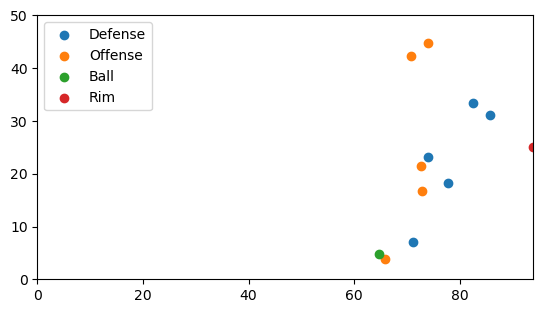

In [19]:
moment = log[13]

import matplotlib.pyplot as plt

xs1 = [a[2] for a in moment[1:6]]
ys1 = [a[3] for a in moment[1:6]]
xs2 = [a[2] for a in moment[6:]]
ys2 = [a[3] for a in moment[6:]]

plt.scatter(xs1, ys1, label="Defense")
plt.scatter(xs2, ys2, label="Offense")
plt.scatter([moment[0][2]], [moment[0][3]], label="Ball")
plt.scatter([94], [25], label="Rim")
plt.xlim(0,94)
plt.ylim(0,50)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

In [20]:
poss_team = 1610612739

data = []
for entry in log:
    pass

In [21]:
import numpy as np

np.random.seed(123)
masses_vec = np.exp(np.random.normal(size=12))

masses = {}
for i, pid in enumerate([-2] + [x[1] for x in moment]):
    masses[pid] = masses_vec[i]

masses

{-2: 0.33768877108424256,
 -1: 2.7110755730711276,
 101106: 1.3270766267777472,
 201575: 0.22173003095331942,
 201939: 0.5606826319607428,
 202691: 5.214465222102194,
 203110: 0.08832966742333861,
 2544: 0.6512168242543143,
 2747: 3.5464115409151904,
 201567: 0.42031939086420933,
 202681: 0.5071816012667562,
 202389: 0.9096376287553738}

In [22]:
if np.mean([x[2] for x in moment]) > 47:
    rim_x, rim_y = 94, 25
else:
    rim_x, rim_y = 0, 25

rim_x, rim_y

(94, 25)

In [23]:
RIM_WEIGHT = 0.2

In [24]:
def get_baseline(locations, player_id, poss_team_id, rim_weight):
    assert rim_weight >= 0 and rim_weight < 1
    # make this into a subroutine
    if np.mean([x[2] for x in moment]) > 47:
        rim_x, rim_y = 94, 25
    else:
        rim_x, rim_y = 0, 25
    # get player coords
    player_x, player_y = None, None
    for entry in locations:
        if entry[1] == player_id:
            player_x = entry[2]
            player_y = entry[3]
    assert player_x is not None and player_y is not None
    # get closest offensive player
    closest = None
    dist = 99999999
    for entry in locations:
        if entry[0] == poss_team_id and entry[1] == player_id:
            raise ValueError(f"Error: player {player_id} is on offense!")
        if entry[0] == poss_team_id:
            # make distance into a subroutine
            d = np.sqrt((entry[2] - player_x)**2 + (entry[3] - player_y)**2)
            if d < dist:
                dist = d
                closest = entry[2], entry[3]
    base_x = (1 - rim_weight) * closest[0] + rim_weight * rim_x
    base_y = (1 - rim_weight) * closest[1] + rim_weight * rim_y
    return base_x, base_y

In [25]:
base_loc = get_baseline(moment, 101106, poss_team, RIM_WEIGHT)
base_loc

(76.943128, 22.158152)

In [26]:
player_x, player_y = 85.76, 31.17

dists = {}
for entry in moment:
    if entry[0] == poss_team or entry[0] == -1:
        dists[entry[1]] = np.sqrt((entry[2] - player_x)**2 + (entry[3] - player_y)**2)

dists[-2] = np.sqrt((rim_x - player_x)**2 + (rim_y - player_y)**2)

dists

{-1: 33.757750252959696,
 2544: 19.316607661802323,
 2747: 16.2984118037372,
 201567: 18.70035504642894,
 202681: 33.8479751628986,
 202389: 18.065486005136982,
 -2: 10.294003108606484}

In [27]:
locations = {}
for entry in moment:
    locations[entry[1]] = (entry[2], entry[3])

locations[-2] = (rim_x, rim_y)

In [28]:
P = 2

hat = list(base_loc)

for _id, dist in dists.items():
    hat[0] += (masses[_id] / (dist**P)) * (locations[_id][0] - player_x)
    hat[1] += (masses[_id] / (dist**P)) * (locations[_id][1] - player_x)

hat

[76.66235897768816, 20.59034676365379]

In [29]:
player_x, player_y

(85.76, 31.17)

In [132]:
# idea: iterate through events, from each event filter to only in-play moments, from in-play moments select one moment every 0.5 or 1.0 secs
# format that data into a usable format (long-form, so each row corresponds to one player-moment and have IDs for player, team, event, moment)
# using that data run the gravity code??

# OFFENSE: use team closest to ball for majority of moments within event to determine team on offense
# RIM: check if players have x-coordinate > 47 or <= 47 to determine which side rim to use

# DISCARD: any moments where there are completely overlapping players (error in tracking I guess?)
# CHECKS: make sure same 10 players are on during successive moments; check to make sure dist traveled is not too crazy
# PADDING: remove first/last 3-ish secs from each event to avoid difficulties with possession change

# hat{location_d} = Baseline + sum_j m_j / r_dj^p u_dj
#    u_dj is vector pointing towards player j
#    Baseline = some convex combination of closest offensive player location and rim location (can optimize for the exact weight of the rim)
#    (Could also just see optimal weight using only rim + closest defender for location prediction to get initial idea)

# alpha_dj = (exp(m_j) / r_dj^p) / (sum of that over all offensive players j)     [weights]
# hat{x_d} = sum_j alpha_dj o_j
#    o_j = location for offensive player j
# L = sum_t sum_d ||x_d - hat{x_d}||^2